## T3

### Import library

In [178]:
import pandas as pd
import numpy as np
from tqdm import tqdm

In [179]:
train_url = "http://s3.amazonaws.com/assets.datacamp.com/course/Kaggle/train.csv"
train = pd.read_csv(train_url)
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [180]:
test_url = "http://s3.amazonaws.com/assets.datacamp.com/course/Kaggle/test.csv"
test = pd.read_csv(test_url)
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


### T8

In [181]:
train['Age'] = train['Age'].fillna(train['Age'].median())

### T9

In [ ]:
def Embark_fillna(data) -> np.ndarray:
    Embark_num = {'S': 0, 'C': 1, 'Q': 2}

    for key, value in Embark_num.items():
        data.loc[data['Embarked'] == key, 'Embarked'] = value

    return data['Embarked'].fillna(data['Embarked'].mode()[0])

def Sex_fillna(data) -> np.ndarray:
    Sex_num = {'male': 0, 'female': 1}

    for key, value in Sex_num.items():
        data.loc[data['Sex'] == key, 'Sex'] = value

    return data['Sex'].fillna(data['Sex'].mode()[0])


### T10

In [ ]:
def add_bias(data) -> np.ndarray:
    m = data.shape[0] # data shape (m, n)
    X = np.ones((m, data.shape[1] + 1))
    X[:, 1:] = data
    return X # Add bias term -> X0 = 1 -> shape (m, n+1)

def data_preparation(data) -> np.ndarray:
    data['Age'] = data['Age'].fillna(data['Age'].median())
    data['Embarked'] = Embark_fillna(data)
    data['Sex'] = Sex_fillna(data)
    features = np.array(data[['Pclass', 'Sex', 'Age', 'Embarked']].values, dtype=np.float64)
    features = (features - features.mean(axis=0)) / features.std(axis=0)
    features = add_bias(features)
    return features

def h(X, theta) -> np.ndarray:
    # X shape (m, n) theta shape (n, )
    return X.dot(theta) # shape (m, )

def cost_function(X, y, theta) -> np.float64:
    m = len(y) # y shape (m, )
    predictions = h(X, theta) # shape (m, )
    cost = (1/2*m) * np.sum(np.square(y - predictions))
    return cost

def update_parameters(X, y, theta, learning_rate) -> np.ndarray:
    m = len(y)
    predictions = h(X, theta) # shape (m, )
    errors = y - predictions # shape (m, )
    gradients = errors.dot(X)
    # print(gradients)
    theta += learning_rate * gradients
    return theta

def gradient_descent(X, y, theta, learning_rate, iterations) -> np.ndarray:
    for _ in tqdm(range(iterations)):
        theta = update_parameters(X, y, theta, learning_rate)
    return theta

def train_model(X, y, learning_rate=0.01, iterations=1000) -> np.ndarray:
    n = X.shape[1]
    theta = [0.5] * n
    theta = gradient_descent(X, y, theta, learning_rate, iterations)
    return theta

In [184]:
# Preprocess training data
features = data_preparation(train)

# train the model
params1 = train_model(features, train['Survived'].values, learning_rate=1e-6, iterations=100000)
print("Trained parameters:", params1)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23224\891176827.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return data['Embarked'].fillna(data['Embarked'].mode()[0])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23224\891176827.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return data['Sex'].fillna(data['Sex'].mode()[0])
100%|██████████| 100000/100000 [00:00<00:00, 183898.27it/s]

Trained parameters: [ 0.38383838 -0.15746036  0.2344979  -0.06576928  0.0312026 ]


In [185]:
def submit_predictions(name, test_features, params, threshold=0.5):
    predictions = h(test_features, params)
    predicted_classes = (predictions >= threshold).astype(int)
    submission = pd.DataFrame({
        'PassengerId': test['PassengerId'],
        'Survived': predicted_classes
    })
    submission.to_csv(f'{name}_predictions.csv', index=False)
    print(f"Submission file created: {name}_predictions.csv")

In [186]:
# Test - Preprocess test data
test_features = data_preparation(test)

# Make predictions
submit_predictions("T10", test_features, params1, threshold=0.5)
# The predictions will be saved in 'titanic_predictions.csv'

Submission file created: T10_predictions.csv


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23224\891176827.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return data['Embarked'].fillna(data['Embarked'].mode()[0])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23224\891176827.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return data['Sex'].fillna(data['Sex'].mode()[0])


### T11

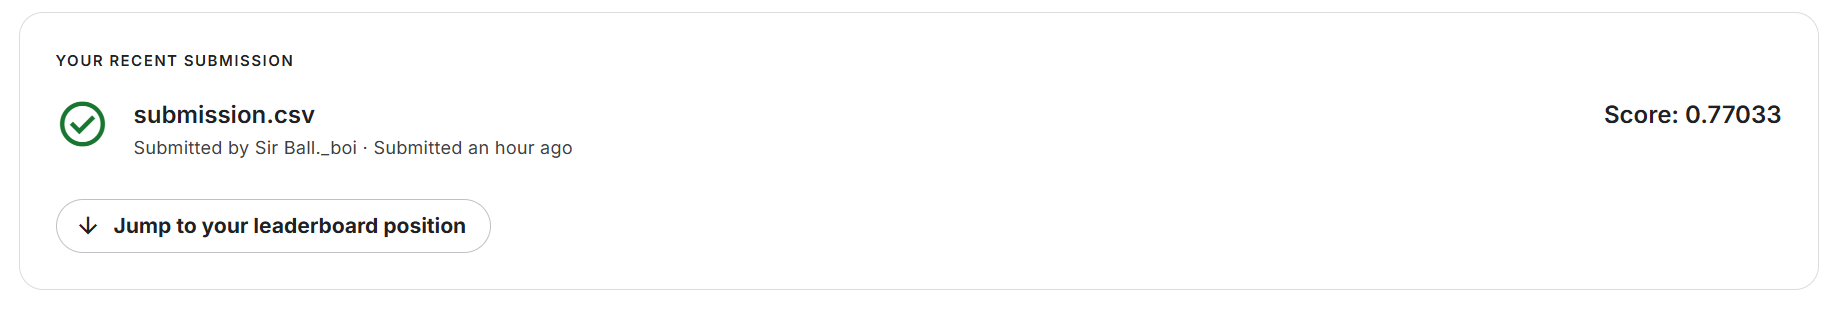

### T12

In [187]:
def add_column(data, col_value) -> np.ndarray:
    m = data.shape[0]
    new_data = np.ones((m, data.shape[1] + 1))
    new_data[:, -1] = col_value
    new_data[:, :-1] = data
    return new_data

In [188]:
data = np.array(train[['Pclass', 'Sex', 'Age', 'Embarked']].values, dtype=np.float64)
data = (data - data.mean(axis=0)) / data.std(axis=0)  # Standardize features
features = add_bias(data)

# Add x1^2
features = add_column(features, features[:, 1]**2)
# Add x1x2
features = add_column(features, features[:, 1] * features[:, 2])

# train the model
params = train_model(features, train['Survived'].values, learning_rate=1e-6, iterations=100000)
print("Trained parameters:", params)

100%|██████████| 100000/100000 [00:00<00:00, 166693.65it/s]

Trained parameters: [ 0.39740099 -0.16763173  0.22941284 -0.06414058  0.03600482 -0.02096251
 -0.05609432]


In [189]:
test_features = data_preparation(test)

# Add x1^2
test_features = add_column(test_features, test_features[:, 1]**2)
# Add x1x2
test_features = add_column(test_features, test_features[:, 1] * test_features[:, 2])

# Make predictions
submit_predictions("T12", test_features, params, threshold=0.5)

Submission file created: T12_predictions.csv


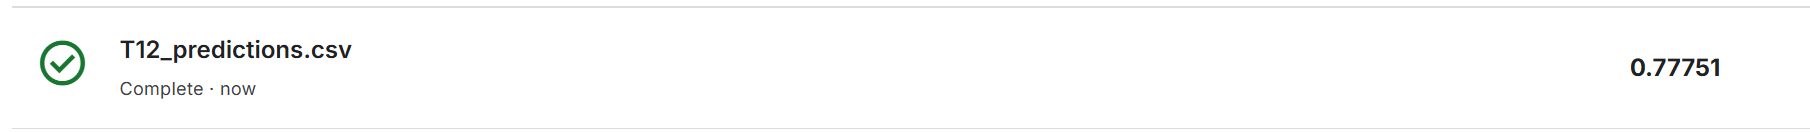

### T13

In [190]:
def data_preparation(data) -> np.ndarray:
    data['Age'] = data['Age'].fillna(data['Age'].median())
    data['Sex'] = Sex_fillna(data)
    features = np.array(data[['Sex', 'Age']].values, dtype=np.float64)
    features = (features - features.mean(axis=0)) / features.std(axis=0)
    features = add_bias(features)
    return features

In [191]:
# Preprocess training data
features = data_preparation(train)

# train the model
params = train_model(features, train['Survived'].values, learning_rate=1e-6, iterations=100000)
print("Trained parameters:", params)

100%|██████████| 100000/100000 [00:00<00:00, 268120.58it/s]

Trained parameters: [ 0.38383838  0.26341541 -0.01018773]


In [192]:
# Testing the model
test_features = data_preparation(test)

# Make predictions
submit_predictions("T13", test_features, params, threshold=0.5)

Submission file created: T13_predictions.csv


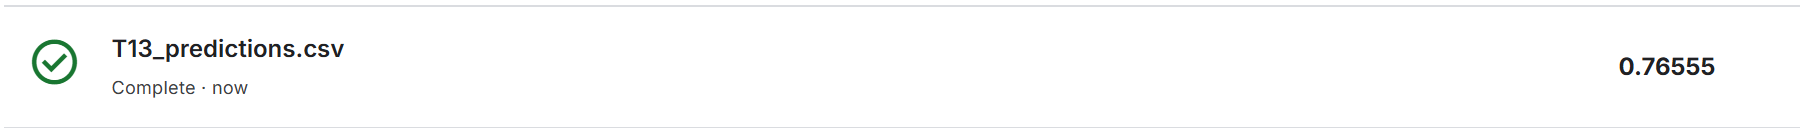

### OT3 free?

### OT4

In [193]:
def normal_equation(X, y) -> np.ndarray:
    X_transpose = X.T
    theta = np.linalg.inv(X_transpose.dot(X)).dot(X_transpose).dot(y)
    return theta

def data_preparation(data) -> np.ndarray:
    data['Age'] = data['Age'].fillna(data['Age'].median())
    data['Embarked'] = Embark_fillna(data)
    data['Sex'] = Sex_fillna(data)
    features = np.array(data[['Pclass', 'Sex', 'Age', 'Embarked']].values, dtype=np.float64)
    features = (features - features.mean(axis=0)) / features.std(axis=0)
    features = add_bias(features)
    return features

In [194]:
# Preprocess training data
features = data_preparation(train)

# Normal equation to train the model
params2 = normal_equation(features, train['Survived'].values)
print("Trained parameters:", params2)

Trained parameters: [ 0.38383838 -0.15746036  0.2344979  -0.06576928  0.0312026 ]


The trained parameters looks really similar to the gradient descent method

In [195]:
# Preprocess testing data
test_features = data_preparation(test)

# Make predictions
submit_predictions("OT4", test_features, params2, threshold=0.5)

Submission file created: OT4_predictions.csv


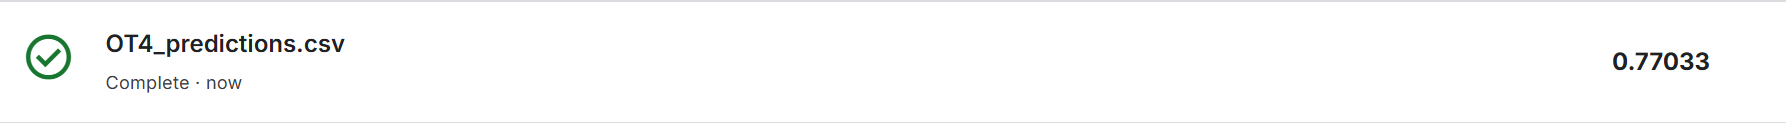

In [196]:
# Report MSE for two different weight
def MSE(theta1, theta2) -> np.float64:
    n = len(theta1)
    mse = (1/n) * np.sum(np.square(theta1 - theta2))
    return mse

In [197]:
MSE(params1, params2)

np.float64(4.724665941369625e-28)